**MOVIE INDUSTRY STRATEGIC ANALYSIS**

**1.OVERVIEW**

The project analyses different types of films from movie datasets to help the head of the company decide on the type of the film to create in the new movie studio.The analysis will focus on establishing the best performing films in the industry based on the data provided.

**2.BUSINESS UNDERSTANDING**


The company wants to enter the movie industry, but they lack experience. The goal of this project is to analyze existing movie data to identify patterns of success and guide decision-making for the new studio

**2.1 Business Questions**

1.Which genres perform best?

2.What budget range is most profitable?

3.What are they doing right?

4.Does release timing matter?

5.What factors drive success?


**2.2 Goal**

Provide data-driven recommendations so the company can:

Reduce risk when investing in movies

Choose the right type of films

Maximize profit and audience reach

**3.DATA UNDERSTANDING**

We used three main data sources:
1.[bom.movie_gross.csv.gz](zippedData/bom.movie_gross.csv.gz)-it shows gross revenue (movies that made the most revenue,studios that produced the highest films)

2.[im.db.zip](zippedData/im.db.zip)-shows the movie genres produced,runtime,year,title and ratings.

3.[tn.movie_budgets.csv.gz](zippedData/tn.movie_budgets.csv.gz)-shows has the movies production budgets,therefore we use to determine the cost and return on investment

**4.DATA PREPARATION AND IMPORTING LIBRARIES**

4.1 Data Loading

In [2]:
#importing libraries
import pandas as pd
import numpy as np
import sqlite3
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

In [3]:
#loading data
bom=pd.read_csv('zippedData/bom.movie_gross.csv.gz')
bom

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018


In [4]:
conn = sqlite3.connect('zippedData im.db.zip')
conn

In [5]:
zip_path = ("im.db.zip")
extract_path = "./"

In [6]:
import zipfile
import os

# Unzip file 
if not os.path.exists('zippedData/im.db'):
    with zipfile.ZipFile('zippedData/im.db.zip', 'r') as zip_ref:
        zip_ref.extractall('zippedData/')
    print("Database unzipped successfully!")

In [7]:
# Connect and list all tables
conn = sqlite3.connect('zippedData/im.db')
cursor = conn.cursor()
tables=pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';",conn)
print(tables)


            name
0   movie_basics
1      directors
2      known_for
3     movie_akas
4  movie_ratings
5        persons
6     principals
7        writers


In [8]:

#Using sqlite3 with pandas
#df=pd.read_sql(query,conn)
#Using sqlite3 with pandas
#df=pd.read_sql(query,conn)
movie_basics=pd.read_sql('SELECT * FROM movie_basics',conn)
movie_basics.head()


,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [9]:
#Using sqlite3 with pandas
#df=pd.read_sql(query,conn)
movie_ratings=pd.read_sql('SELECT * FROM movie_ratings',conn)
movie_ratings.head()

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [10]:
tn=pd.read_csv('zippedData/tn.movie_budgets.csv.gz')
tn

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
...,...,...,...,...,...,...
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0


**4.2 DETAILED DATA CLEANING**


In [11]:
#cleaning the bom.movie_gross.csv.gz
#Data Inspecting

In [12]:
def inspect(df, name):
    print(f"\n--- {name} ---")
    print(df.head())
    print(df.info())
    print(df.describe(include='all'))

inspect(bom, 'BOM Movie Gross')
inspect(tn, 'TN Movie Budgets')
inspect(tables, 'IMDB Movies')


--- BOM Movie Gross ---
                                         title studio  domestic_gross  \
0                                  Toy Story 3     BV     415000000.0   
1                   Alice in Wonderland (2010)     BV     334200000.0   
2  Harry Potter and the Deathly Hallows Part 1     WB     296000000.0   
3                                    Inception     WB     292600000.0   
4                          Shrek Forever After   P/DW     238700000.0   

  foreign_gross  year  
0     652000000  2010  
1     691300000  2010  
2     664300000  2010  
3     535700000  2010  
4     513900000  2010  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year       

In [13]:
# check missing values in each dataset
print("BOM Movie Gross missing values:")
print(bom.isnull().sum())

print("\nTN Movie Budgets missing values:")
print(tn.isnull().sum())

print("\nIMDB Movies (movie_basics) missing values:")
print(tables.isnull().sum())

BOM Movie Gross missing values:
title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

TN Movie Budgets missing values:
id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64

IMDB Movies (movie_basics) missing values:
name    0
dtype: int64


In [14]:
## Establishing the data types of foreign gross
bom['foreign_gross'].dtype

dtype('O')

In [15]:
#Establishing the data types of domestic gross
bom['domestic_gross'].dtype

dtype('float64')

In [16]:
#Establishing the data types of domestic gross
bom['studio'].dtype

dtype('O')

In [17]:
#Converting foreign_gross
bom['foreign_gross'] = pd.to_numeric(bom['foreign_gross'], errors='coerce')

In [18]:
#Converting Date into Datetime
#For bom.movie_gross data, we are using the year column
# Convert Year to integer
bom['year'] = bom['year'].astype(int)

#For tn.movie_budgets, we format the release_date column
tn['release_date'] = pd.to_datetime(tn['release_date'])

#Extract Month and Year
tn['release_month'] = tn['release_date'].dt.month
tn['release_year'] = tn['release_date'].dt.year

In [19]:
# Clean TN Movie Budgets 
# Remove $ and commas
cols = ['production_budget', 'domestic_gross', 'worldwide_gross']

for col in cols:
    tn[col] = tn[col].replace({'\$': '', ',': ''}, regex=True)
    tn[col] = pd.to_numeric(tn[col], errors='coerce')

In [20]:
#Clean Movie_basics  Data
movie_basics.columns

Index(['movie_id', 'primary_title', 'original_title', 'start_year',
       'runtime_minutes', 'genres'],
      dtype='object')

In [21]:
# Keep only relevant columns
movie_basics = movie_basics[['movie_id', 'primary_title', 'original_title', 'start_year',
       'runtime_minutes', 'genres']]
# Rename for merging
movie_basics.rename(columns={'primary_title': 'title'}, inplace=True)

In [22]:
#checking columns in movie_ratings data
movie_ratings.columns

Index(['movie_id', 'averagerating', 'numvotes'], dtype='object')

In [23]:
# Cleaning Movie_ratings data
# Merge ratings with movie_basics
ratings_basics = pd.merge(movie_basics, movie_ratings, on='movie_id', how='inner')

In [24]:
# Lowercase titles for consistency
bom['title'] = bom['title'].str.lower()
tn['movie'] = tn['movie'].str.lower()
ratings_basics['title'] = ratings_basics['title'].str.lower()

In [25]:
#Replacing missing values
#Replacing studio value
bom['studio']=bom['studio'].fillna('unknown')
#Replacing domestic_grosss missing values
domestic_median=bom['domestic_gross'].median()
bom['domestic_gross'] = bom['domestic_gross'].fillna(domestic_median)
#Replacing foreign_grosss missing values
foreign_mean = bom['foreign_gross'].mean()
bom['foreign_gross'] = bom['foreign_gross'].fillna(foreign_mean)


In [26]:
# Merging Datasets
# Merge revenue + budget
merged = pd.merge(
    bom,
    tn,
    left_on='title',
    right_on='movie',
    how='inner'
)

In [27]:
# Merge with ratings
merged_1 = pd.merge(
    merged,
    ratings_basics,
    on='title',
    how='inner'
)

In [28]:
#Final Data Cleaning on the merged dataset
merged_1.isnull().sum()
merged_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1471 entries, 0 to 1470
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   title              1471 non-null   object        
 1   studio             1471 non-null   object        
 2   domestic_gross_x   1471 non-null   float64       
 3   foreign_gross      1471 non-null   float64       
 4   year               1471 non-null   int32         
 5   id                 1471 non-null   int64         
 6   release_date       1471 non-null   datetime64[ns]
 7   movie              1471 non-null   object        
 8   production_budget  1471 non-null   int64         
 9   domestic_gross_y   1471 non-null   int64         
 10  worldwide_gross    1471 non-null   int64         
 11  release_month      1471 non-null   int32         
 12  release_year       1471 non-null   int32         
 13  movie_id           1471 non-null   object        
 14  original

In [29]:
#Validate the Merge
merged_1.shape

(1471, 20)

In [30]:
#Standardize data formats
# Make sure string columns are consistent
merged_1['title'] = merged_1['title'].astype(str)
merged_1['studio'] = merged_1['studio'].astype(str)


In [31]:
#Check duplicates in merged dataset
merged_1.duplicated().sum()

0

In [32]:
#Display the duplicate rows
merged_1[merged_1.duplicated()]

,title,studio,domestic_gross_x,foreign_gross,year,id,release_date,movie,production_budget,domestic_gross_y,worldwide_gross,release_month,release_year,movie_id,original_title,start_year,runtime_minutes,genres,averagerating,numvotes


In [33]:
#Check duplicates based on key column(title,release year)
merged_1.duplicated(subset=['title','movie_id', 'release_year']).sum()

0

In [34]:
#Check using multiple columns
merged_1.duplicated(subset=['title', 'movie_id','release_year']).sum()

0

In [35]:
#view duplicates
merged_1[merged_1.duplicated(subset=['title','movie_id', 'release_year'], keep=False)]

,title,studio,domestic_gross_x,foreign_gross,year,id,release_date,movie,production_budget,domestic_gross_y,worldwide_gross,release_month,release_year,movie_id,original_title,start_year,runtime_minutes,genres,averagerating,numvotes


In [36]:
#See ALL duplicate entries
merged_1[merged_1.duplicated(subset=['title'], keep=False)]


,title,studio,domestic_gross_x,foreign_gross,year,id,release_date,movie,production_budget,domestic_gross_y,worldwide_gross,release_month,release_year,movie_id,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
9,the karate kid,Sony,176600000.0,1.825000e+08,2010,77,2010-06-11,the karate kid,40000000,176591618,351774938,6,2010,tt1155076,The Karate Kid,2010,140.0,"Action,Drama,Family",6.2,146401
10,the karate kid,Sony,176600000.0,1.825000e+08,2010,63,1984-06-22,the karate kid,8000000,90815558,90815558,6,1984,tt1155076,The Karate Kid,2010,140.0,"Action,Drama,Family",6.2,146401
13,robin hood,Uni.,105300000.0,2.164000e+08,2010,39,2010-05-14,robin hood,210000000,105487148,322459006,5,2010,tt0955308,Robin Hood,2010,140.0,"Action,Adventure,Drama",6.6,239480
14,robin hood,Uni.,105300000.0,2.164000e+08,2010,39,2010-05-14,robin hood,210000000,105487148,322459006,5,2010,tt2363363,Robin Hood,2013,92.0,"Action,Drama",6.3,78
15,robin hood,Uni.,105300000.0,2.164000e+08,2010,39,2010-05-14,robin hood,210000000,105487148,322459006,5,2010,tt4532826,Robin Hood,2018,116.0,"Action,Adventure,Thriller",5.3,41588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,upgrade,BH Tilt,12000000.0,2.400000e+06,2018,89,2018-06-01,upgrade,3000000,11977130,16553285,6,2018,tt6739824,Upgrade,2016,NaN,Drama,8.8,69
1459,kin,LGF,5700000.0,4.300000e+06,2018,88,2018-08-31,kin,30000000,5718096,10096821,8,2018,tt2233624,Kin,2012,45.0,"Drama,Music",8.6,46
1460,kin,LGF,5700000.0,4.300000e+06,2018,88,2018-08-31,kin,30000000,5718096,10096821,8,2018,tt6017942,Kin,2018,102.0,"Action,Drama,Sci-Fi",5.7,9048
1468,mandy,RLJ,1200000.0,7.505704e+07,2018,71,2018-09-14,mandy,6000000,1214525,1427656,9,2018,tt4995858,Mandy,2016,113.0,"Drama,Thriller",4.1,39


In [37]:
#Remove duplicates
# Check duplicates first
merged_1[merged_1.duplicated(subset=['title', 'release_year'], keep=False)]
# Drop duplicates (keep first)
merged_1 = merged_1.drop_duplicates(subset=['title', 'release_year'], keep='first')

In [38]:
#standardize string values
merged_1['studio'] = merged_1['studio'].str.lower().str.strip()
merged_1['title'] = merged_1['title'].str.strip()

In [39]:
#filter out bad data
# Example: remove movies with zero or negative budgets
merged_1 = merged_1[merged_1['production_budget'] > 0]
# Remove rows with negative or zero gross
merged_1 = merged_1[merged_1['worldwide_gross'] > 0]

In [40]:
# remove top 1% extreme domestic gross values
domestic_upper = merged_1['domestic_gross_y'].quantile(0.99)
merged_1 = merged_1[merged_1['domestic_gross_y'] <= domestic_upper]

In [41]:
#rename column
merged_1 = merged_1.rename(columns={
    'domestic_gross_x': 'domestic_gross_old_source',
    'domestic_gross_y': 'domestic_gross',
    'release_year': 'year_released'
})

In [42]:
#save cleaned data
merged_1.to_csv('cleaned_merged_data.csv', index=False)

**TOTAL REVENUE BIGGEST SUCCESS METRICS**

In [43]:
# Create total gross:
bom['total_gross'] = bom['domestic_gross'] + bom['foreign_gross']

In [44]:
# Top-performing movies
# Focus on high-revenue genres
bom.sort_values('total_gross', ascending=False).head(10)

,title,studio,domestic_gross,foreign_gross,year,total_gross
727,marvel's the avengers,BV,623400000.0,895500000.0,2012,1.518900e+09
1875,avengers: age of ultron,BV,459000000.0,946400000.0,2015,1.405400e+09
3080,black panther,BV,700100000.0,646900000.0,2018,1.347000e+09
328,harry potter and the deathly hallows part 2,WB,381000000.0,960500000.0,2011,1.341500e+09
2758,star wars: the last jedi,BV,620200000.0,712400000.0,2017,1.332600e+09
3081,jurassic world: fallen kingdom,Uni.,417700000.0,891800000.0,2018,1.309500e+09
1127,frozen,BV,400700000.0,875700000.0,2013,1.276400e+09
2759,beauty and the beast (2017),BV,504000000.0,759500000.0,2017,1.263500e+09
3082,incredibles 2,BV,608600000.0,634200000.0,2018,1.242800e+09
1128,iron man 3,BV,409000000.0,805800000.0,2013,1.214800e+09


In [45]:
# Studio performance
bom.groupby('studio')['total_gross'].mean().sort_values(ascending=False)

studio
HC              8.703000e+08
P/DW            5.076500e+08
BV              4.199350e+08
GrtIndia        2.542000e+08
WB (NL)         2.313279e+08
                    ...     
FOAK            1.243000e+05
IVP             1.121000e+05
Darin Southa    9.840000e+04
ITL             5.290000e+04
WOW             4.940000e+04
Name: total_gross, Length: 258, dtype: float64

In [46]:
# Yearly trends
bom.groupby('year')['total_gross'].mean()

# Is revenue growing over time

year
2010    7.801519e+07
2011    8.444609e+07
2012    9.795712e+07
2013    1.094143e+08
2014    9.898547e+07
2015    1.020482e+08
2016    1.111597e+08
2017    1.301988e+08
2018    1.258878e+08
Name: total_gross, dtype: float64

In [47]:
# Domestic vs Foreign market
# Global appeal is critical
# Think globally, not locally
bom[['domestic_gross', 'foreign_gross']].mean()

domestic_gross    2.851978e+07
foreign_gross     7.505704e+07
dtype: float64

In [48]:
# Budget vs revenue (if merged with tn dataset)
# Budget strategically
# High budget ≠ guaranteed success
# ROI matters more than revenue
merged_1['profit'] = merged_1['worldwide_gross'] - merged_1['production_budget']
# ROI
merged_1['roi'] = merged_1['profit'] / merged_1['production_budget']

In [49]:
# Learn from top studios
# Genre choices, Release timing and Franchise strategy

In [51]:
merged_1.columns

Index(['title', 'studio', 'domestic_gross_old_source', 'foreign_gross', 'year',
       'id', 'release_date', 'movie', 'production_budget', 'domestic_gross',
       'worldwide_gross', 'release_month', 'year_released', 'movie_id',
       'original_title', 'start_year', 'runtime_minutes', 'genres',
       'averagerating', 'numvotes', 'profit', 'roi'],
      dtype='object')

Visualization

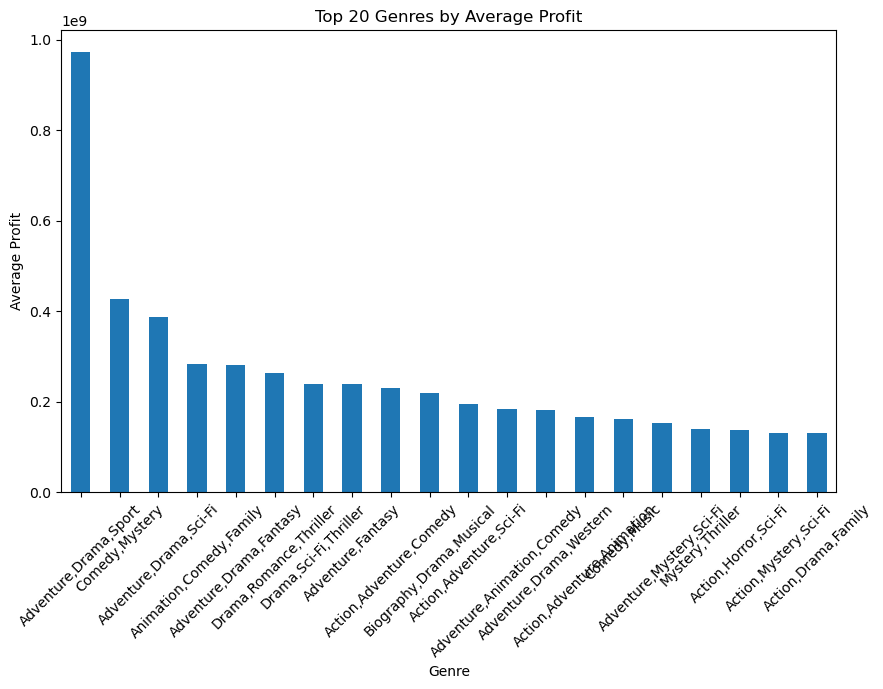

In [55]:
import matplotlib.pyplot as plt

# Ensure profit exists
merged_1['profit'] = merged_1['profit'] - merged_1['production_budget']

# If genres are in one column like "Action|Adventure"
merged_1 = merged_1.assign(genre=merged_1['genres'].str.split('|')).explode('genre')

# Group and get top 20
genre_profit = (
    merged_1.groupby('genres')['profit']
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

# Plot
genre_profit.plot(kind='bar', figsize=(10,6))
plt.title('Top 20 Genres by Average Profit')
plt.xlabel('Genre')
plt.ylabel('Average Profit')
plt.xticks(rotation=45)
plt.show()

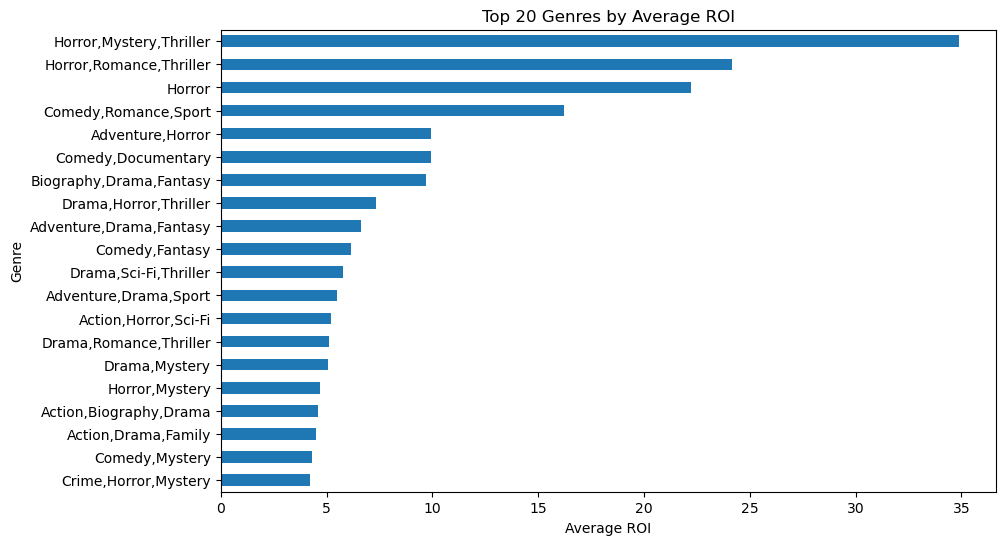

In [70]:
#3 Return on Investment per genre

# Ensure ROI exists
merged_1['ROI'] = (merged_1['profit'] - merged_1['production_budget']) / merged_1['production_budget']

# If genres are combined (e.g., "Action|Adventure")
merged_1 = merged_1.assign(genre=merged_1['genres'].str.split('|')).explode('genre')

# Calculate average ROI per genre
roi_genre = (
    merged_1.groupby('genres')['ROI']
    .mean()
    .sort_values(ascending=True)   # ascending for horizontal bar
    .tail(20)  # top 20 genres
)

# Plot horizontal bar chart
roi_genre.plot(kind='barh', figsize=(10,6))

plt.title('Top 20 Genres by Average ROI')
plt.xlabel('Average ROI')
plt.ylabel('Genre')
plt.show()